<a href="https://colab.research.google.com/github/EzeRivero/Data-Science-III/blob/main/DS3_Rivero_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data Science III: Entrega Final**
##Ezequiel Rivero
###Comisión 77795

#Introducción
El análisis de sentimientos es una de las aplicaciones más potentes del procesamiento de lenguaje natural (NLP). En este proyecto, nos sumergimos en un dataset de reseñas de espectadores extraídas de Rotten Tomatoes. El desafío principal es tomar todo este texto cargado de opiniones, modismos y críticas directas sobre películas y series, y procesarlo para que una máquina pueda entenderlo. La idea es construir un flujo de trabajo que vaya desde la limpieza de estas opiniones y la extracción de su estructura base, hasta el entrenamiento de una red neuronal profunda capaz de clasificar automáticamente si el público aprobó o rechazó lo que vio en pantalla.

El dataset fue tomado desde Kaggle.com, y se utilizará una muestra representativa del total del dataset, para optimizar tiempos de procesamiento.

#Objetivo
El objetivo central es desarrollar un modelo de Deep Learning capaz de leer una reseña cinematográfica y predecir con precisión si el sentimiento del usuario es positivo o negativo. Para lograr esto, se trabajará en la limpieza profunda del texto (eliminando ruido y estandarizando palabras) y se transformará ese lenguaje natural en representaciones numéricas mediante TF-IDF. Finalmente, se busca que la red neuronal aprenda a identificar de manera autónoma los patrones y el vocabulario que definen una buena o mala crítica dentro de la plataforma.

#Contexto Comercial
En la industria del entretenimiento y el streaming, el volumen de feedback generado por los usuarios es masivo y constante. Procesar y clasificar manualmente estas reseñas es técnica y financieramente inviable. Implementar un modelo de análisis de sentimiento automatizado permite a las plataformas cuantificar de manera casi instantánea la recepción del público ante un nuevo lanzamiento. Este tipo de herramientas NLP resulta vital para el negocio: facilita la toma de decisiones ágiles, permite ajustar campañas de marketing en tiempo real, ayuda a identificar problemas con el contenido y alimenta de forma directa los algoritmos de recomendación, mejorando en última instancia la retención del usuario.

#Hipótesis
La hipótesis a demostrar es que, mediante una limpieza exhaustiva del texto y la aplicación de TF-IDF para ponderar la relevancia de los términos, una red neuronal densa logrará identificar patrones de vocabulario y clasificar los sentimientos de las reseñas con un nivel de precisión (Accuracy/F1-Score) significativamente superior al azar. Sin embargo, también se asume que el modelo encontrará su mayor limitación frente al sarcasmo o la ironía, o respuestas con más de un sentido. Al depender del conteo y peso de las palabras pero descartar su orden secuencial, se espera que el modelo pierda ciertos matices contextuales propios de la crítica de cine.

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from collections import Counter

# 1. Cargar datos
url = 'https://raw.githubusercontent.com/EzeRivero/Data-Science-III/refs/heads/main/audience_reviews.csv'
df = pd.read_csv(url)

df.head()

,Show,Rating,Review
0,Test,0.0,Test review
1,Loot,2.5,"I love the stars, but the show is riddled with..."
2,Loot,4.5,Great show to watch. It's something that's eas...
3,Loot,0.5,Another Apple tanker crashes into the reef wit...
4,Loot,4.5,"This is such a fun, endearing show. It has a ..."


In [14]:
df.info

(65522, 3)

In [17]:
df.describe()

,Rating
count,65522.000000
mean,3.514659
std,1.738253
min,0.000000
25%,2.000000
50%,4.500000
75%,5.000000
max,5.000000


In [24]:
# 2. Crear la variable objetivo (Clasificación Binaria)
# Consideramos reseñas > 3.0 como Positivas (1) y <= 3.0 como Negativas (0)
df['Sentimiento'] = df['Rating'].apply(lambda x: 1 if x > 3.0 else 0)

# 4. Reducir el dataset a 10000 registros manteniendo la proporción de clases (estratificado)
# Usamos train_test_split para tomar la muestra de forma rápida y balanceada
df_sample, _ = train_test_split(df, train_size=10000, stratify=df['Sentimiento'], random_state=42)

# Verificamos
print(df_sample['Sentimiento'].value_counts())

Sentimiento
1    6407
0    3593
Name: count, dtype: int64


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


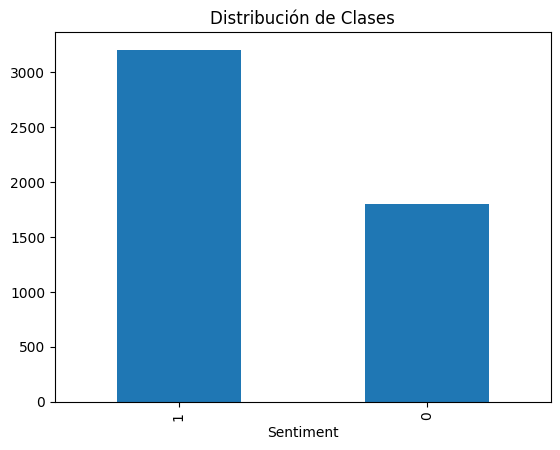

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')
nlp = spacy.load("en_core_web_sm")

# --- EDA Básico ---
# Gráfico de distribución de clases
df_sample['Sentimiento'].value_counts().plot(kind='bar', title='Distribución de Clases')
plt.show()

# --- Pipeline de Limpieza Regex ---
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Quitar URLs
    text = re.sub(r'\@\w+|\#', '', text) # Quitar menciones y hashtags
    text = re.sub(r'[^\w\s]', '', text) # Quitar signos de puntuación y caracteres especiales
    return text

df_sample['Clean_Review'] = df_sample['Review'].apply(clean_text)

# --- Comparación de Lematización (NLTK vs spaCy) ---
# NLTK
lemmatizer = WordNetLemmatizer()
def lemmatize_nltk(text):
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(word) for word in tokens])

# spaCy
def lemmatize_spacy(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc if not token.is_stop])

# Aplicamos spaCy para el modelado por ser más preciso contextualmente
df_sample['Lemmatized_Review'] = df_sample['Clean_Review'].apply(lemmatize_spacy)

# --- Vectorización TF-IDF ---
vectorizer = TfidfVectorizer(max_features=3000) # Limitamos a las 3000 palabras más relevantes
X = vectorizer.fit_transform(df_sample['Lemmatized_Review']).toarray()
y = df_sample['Sentiment'].values

# División en Train y Validation para PyTorch
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convertir arrays a Tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long) # CrossEntropy requiere formato long
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64, shuffle=False)

# --- Arquitectura del Modelo ---
class TextClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(TextClassifier, self).__init__()
        # Capa 1
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(p=0.5)
        self.relu = nn.ReLU()
        # Capa 2
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        # Capa de Salida
        self.out = nn.Linear(hidden_dim // 2, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.out(x)
        return x

# Instanciar modelo, pérdida y optimizador
input_dim = X.shape[1] # 3000 si pusiste max_features=3000
model = TextClassifier(input_dim=input_dim, hidden_dim=128, num_classes=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Bucle de Entrenamiento y Early Stopping ---
epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validación
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

    val_loss /= len(val_loader)
    accuracy = 100 * correct / total

    print(f'Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f} | Val Acc: {accuracy:.2f}%')

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # torch.save(model.state_dict(), 'best_model.pth') # Opcional: guardar el mejor modelo
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping activado en la época {epoch+1}. La pérdida de validación no mejoró en 5 épocas.")
            break

Epoch 1 | Train Loss: 0.5562 | Val Loss: 0.5054 | Val Acc: 83.10%
Epoch 2 | Train Loss: 0.3094 | Val Loss: 0.3528 | Val Acc: 85.70%
Epoch 3 | Train Loss: 0.1981 | Val Loss: 0.3869 | Val Acc: 83.30%
Epoch 4 | Train Loss: 0.1330 | Val Loss: 0.4060 | Val Acc: 83.10%
Epoch 5 | Train Loss: 0.1028 | Val Loss: 0.4670 | Val Acc: 81.70%
Epoch 6 | Train Loss: 0.0844 | Val Loss: 0.4909 | Val Acc: 81.70%
Epoch 7 | Train Loss: 0.0612 | Val Loss: 0.5385 | Val Acc: 81.50%
Early stopping activado en la época 7. La pérdida de validación no mejoró en 5 épocas.
